# Análisis de Rentabilidad y Desempeño Financiero

## Objetivo

Analizar el comportamiento de los ingresos, costos y rentabilidad de una empresa comercial, identificando patrones y diferencias relevantes por período, producto, categoría, región y segmento de clientes.

## Preguntas de negocio

1. ¿Cómo evolucionan los ingresos a través del tiempo?
2. ¿Cómo se comportan los costos?
3. ¿Cómo evoluciona la rentabilidad?
4. ¿Qué productos o categorías tienen mayor contribución?
5. ¿Existen diferencias entre regiones?
6. ¿Qué segmentos de clientes presentan diferencias relevantes?
7. ¿Qué hallazgos pueden apoyar decisiones comerciales y financieras?


In [312]:
import pandas as pd

df = pd.read_csv("../data/superstore.csv")

In [313]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [314]:
df.shape

(10800, 21)

In [315]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [316]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  str    
 1   Order ID       10800 non-null  str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       99

In [317]:
df.isna().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [318]:
df.duplicated().sum()

np.int64(504)

In [319]:
df.dtypes

Row ID               str
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

In [320]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 3. Revisión de calidad de los datos

La exploración inicial del dataset muestra 10.800 registros y 21 columnas.

Se identificaron 806 registros con valores nulos en la mayoría de las variables de negocio y 817 valores nulos en Postal Code.

También se identificaron 504 registros duplicados.

Antes de realizar la limpieza, se analizará la naturaleza de estos registros para determinar si corresponden a filas vacías, duplicados reales u otras inconsistencias.

In [321]:
df[df["Sales"].isna()].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9994,Person,Region,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9996,Chuck Magee,East,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [322]:
df[df["Sales"].isna()].tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10795,Yes,US-2018-147886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10796,Yes,US-2018-147998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10797,Yes,US-2018-151127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10798,Yes,US-2018-155999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10799,Yes,US-2018-155999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [323]:
df[df["Sales"].isna()].shape

(806, 21)

In [324]:
df[df["Sales"].isna()].notna().sum()

Row ID           806
Order ID         806
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [325]:
df[df["Sales"].isna()].isna().sum()

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      806
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64

In [326]:
df[df.duplicated(keep=False)].sort_values("Order ID").head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10000,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10001,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10002,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003,Yes,CA-2015-100762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10006,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10008,Yes,CA-2015-102652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10010,Yes,CA-2015-103744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10011,Yes,CA-2015-103744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [327]:
df[df.duplicated(keep=False)].shape

(710, 21)

In [328]:
df.dropna(subset=["Sales"]).duplicated().sum()

np.int64(0)

In [329]:
df["Row ID"].duplicated().sum()

np.int64(799)

In [330]:
df["Row ID"].nunique()

10001

In [331]:
df["Order ID"].nunique()

5015

In [332]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

In [333]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [334]:
df["Order Date"].isna().sum()

np.int64(806)

In [335]:
df["Ship Date"].isna().sum()

np.int64(806)

In [336]:
df_clean = df.dropna(subset=["Sales"]).copy()

In [337]:
df_clean.shape

(9994, 21)

In [338]:
df_clean.duplicated().sum()

np.int64(0)

In [339]:
df[df["Sales"].isna()].shape

(806, 21)

In [340]:
df[df["Sales"].isna()].notna().sum()

Row ID           806
Order ID         806
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [341]:
df.dropna(subset=["Sales"]).duplicated().sum()

np.int64(0)

In [342]:
df["Row ID"].duplicated().sum()

np.int64(799)

In [343]:
df["Row ID"].nunique()

10001

In [344]:
df["Order ID"].nunique()

5015

In [345]:
df[df.duplicated(keep=False)].sort_values("Order ID").head(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10000,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10001,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10002,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003,Yes,CA-2015-100762,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10006,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10007,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10008,Yes,CA-2015-102652,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10010,Yes,CA-2015-103744,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10011,Yes,CA-2015-103744,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [346]:
df[df["Sales"].isna()][["Row ID", "Order ID", "Order Date", "Profit"]].head(20)

,Row ID,Order ID,Order Date,Profit
9994,Person,Region,NaT,NaN
9995,Anna Andreadi,West,NaT,NaN
9996,Chuck Magee,East,NaT,NaN
9997,Kelly Williams,Central,NaT,NaN
9998,Cassandra Brandow,South,NaT,NaN
9999,Returned,Order ID,NaT,NaN
10000,Yes,CA-2015-100762,NaT,NaN
10001,Yes,CA-2015-100762,NaT,NaN
10002,Yes,CA-2015-100762,NaT,NaN
10003,Yes,CA-2015-100762,NaT,NaN


In [347]:
df[df["Sales"].isna()]["Row ID"].value_counts().head(20)

Row ID
Yes                  800
Person                 1
Anna Andreadi          1
Chuck Magee            1
Kelly Williams         1
Cassandra Brandow      1
Returned               1
Name: count, dtype: int64

In [348]:
df[df["Sales"].isna()][["Row ID", "Order ID", "Customer Name", "Product Name"]].head(20)

,Row ID,Order ID,Customer Name,Product Name
9994,Person,Region,NaN,NaN
9995,Anna Andreadi,West,NaN,NaN
9996,Chuck Magee,East,NaN,NaN
9997,Kelly Williams,Central,NaN,NaN
9998,Cassandra Brandow,South,NaN,NaN
9999,Returned,Order ID,NaN,NaN
10000,Yes,CA-2015-100762,NaN,NaN
10001,Yes,CA-2015-100762,NaN,NaN
10002,Yes,CA-2015-100762,NaN,NaN
10003,Yes,CA-2015-100762,NaN,NaN


In [349]:
df[df["Sales"].isna()].tail(20)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10780,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10781,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10782,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10783,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10784,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10785,Yes,US-2018-118087,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10786,Yes,US-2018-123834,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10787,Yes,US-2018-136679,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10788,Yes,US-2018-136679,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10789,Yes,US-2018-147886,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [350]:
df_clean = df.dropna(subset=["Sales"]).copy()

In [351]:
df_clean.shape

(9994, 21)

## Nuestra limpieza

Se excluyeron 806 registros sin información de ventas ni datos completos de negocio. Los 9.994 registros restantes no presentan duplicados exactos, por lo que no fue necesario aplicar una eliminación adicional de duplicados.

In [352]:
df_clean.shape

(9994, 21)

In [353]:
df_clean.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [354]:
df_clean.duplicated().sum()

np.int64(0)

In [355]:
df_clean[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [356]:
df_clean[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [357]:
df_clean[["Order Date", "Ship Date"]].isna().sum()

Order Date    0
Ship Date     0
dtype: int64

In [358]:
df_clean["Order Date"].min(), df_clean["Order Date"].max()

(Timestamp('2015-01-03 00:00:00'), Timestamp('2018-12-30 00:00:00'))

In [359]:
df_clean["Cost"] = df_clean["Sales"] - df_clean["Profit"]

In [360]:
df_clean["Profit Margin"] = df_clean["Profit"] / df_clean["Sales"]

In [361]:
df_clean[["Sales", "Cost", "Profit", "Profit Margin"]].head(10)

,Sales,Cost,Profit,Profit Margin
0,261.9600,220.0464,41.9136,0.1600
1,731.9400,512.3580,219.5820,0.3000
2,14.6200,7.7486,6.8714,0.4700
3,957.5775,1340.6085,-383.0310,-0.4000
4,22.3680,19.8516,2.5164,0.1125
5,48.8600,34.6906,14.1694,0.2900
6,7.2800,5.3144,1.9656,0.2700
7,907.1520,816.4368,90.7152,0.1000
8,18.5040,12.7215,5.7825,0.3125
9,114.9000,80.4300,34.4700,0.3000


In [362]:
(df_clean["Sales"] - df_clean["Profit"] - df_clean["Cost"]).abs().max()

np.float64(0.0)

In [363]:
df_clean["Profit Margin"].describe()

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [364]:
df_clean["Profit"].sum() / df_clean["Sales"].sum()

np.float64(0.12467217240315605)

In [365]:
df_clean["Cost"] = df_clean["Sales"] - df_clean["Profit"]

In [366]:
df_clean["Profit Margin"] = df_clean["Profit"] / df_clean["Sales"]

In [367]:
df_clean[["Sales", "Cost", "Profit", "Profit Margin"]].head(10)

,Sales,Cost,Profit,Profit Margin
0,261.9600,220.0464,41.9136,0.1600
1,731.9400,512.3580,219.5820,0.3000
2,14.6200,7.7486,6.8714,0.4700
3,957.5775,1340.6085,-383.0310,-0.4000
4,22.3680,19.8516,2.5164,0.1125
5,48.8600,34.6906,14.1694,0.2900
6,7.2800,5.3144,1.9656,0.2700
7,907.1520,816.4368,90.7152,0.1000
8,18.5040,12.7215,5.7825,0.3125
9,114.9000,80.4300,34.4700,0.3000


In [368]:
(df_clean["Sales"] - df_clean["Profit"] - df_clean["Cost"]).abs().max()

np.float64(0.0)

In [369]:
(df_clean["Sales"] - df_clean["Profit"] - df_clean["Cost"]).abs().max()

np.float64(0.0)

In [370]:
df_clean["Profit Margin"].describe()

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [371]:
df_clean["Profit"].sum() / df_clean["Sales"].sum()

np.float64(0.12467217240315605)

In [372]:
total_sales = df_clean["Sales"].sum()
total_cost = df_clean["Cost"].sum()
total_profit = df_clean["Profit"].sum()
total_margin = total_profit / total_sales

total_sales, total_cost, total_profit, total_margin

(np.float64(2297200.8603),
 np.float64(2010803.8386000001),
 np.float64(286397.0217),
 np.float64(0.12467217240315605))

In [373]:
df_clean["Year-Month"] = df_clean["Order Date"].dt.to_period("M")

In [374]:
monthly_financials = (
    df_clean
    .groupby("Year-Month")
    .agg(
        Sales=("Sales", "sum"),
        Cost=("Cost", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

In [375]:
monthly_financials["Profit Margin"] = (
    monthly_financials["Profit"] / monthly_financials["Sales"]
)

In [376]:
monthly_financials.head(10)

,Year-Month,Sales,Cost,Profit,Profit Margin
0,2015-01,14236.8950,11786.7043,2450.1907,0.172101
1,2015-02,4519.8920,3657.5836,862.3084,0.190781
2,2015-03,55691.0090,55192.2791,498.7299,0.008955
3,2015-04,28295.3450,24806.5098,3488.8352,0.123301
4,2015-05,23648.2870,20909.5774,2738.7096,0.115810
5,2015-06,34595.1276,29618.6032,4976.5244,0.143850
6,2015-07,33946.3930,34787.8756,-841.4826,-0.024789
7,2015-08,27909.4685,22591.3635,5318.1050,0.190548
8,2015-09,81777.3508,73449.2514,8328.0994,0.101839
9,2015-10,31453.3930,28005.1357,3448.2573,0.109631


In [377]:
monthly_financials.tail(10)

,Year-Month,Sales,Cost,Profit,Profit Margin
38,2018-03,58872.3528,44120.4613,14751.8915,0.250574
39,2018-04,36521.5361,35588.2461,933.2900,0.025555
40,2018-05,44261.1102,37918.5274,6342.5828,0.143299
41,2018-06,52981.7257,44758.3900,8223.3357,0.155211
42,2018-07,45264.4160,38311.7948,6952.6212,0.153600
43,2018-08,63120.8880,54079.9323,9040.9557,0.143232
44,2018-09,87866.6520,76875.0964,10991.5556,0.125094
45,2018-10,77776.9232,68501.6477,9275.2755,0.119255
46,2018-11,118447.8250,108757.7213,9690.1037,0.081809
47,2018-12,83829.3188,75345.9720,8483.3468,0.101198


In [378]:
monthly_financials.shape

(48, 5)

In [379]:
monthly_financials["Profit"].min(), monthly_financials["Profit"].max()

(np.float64(-3281.007), np.float64(17885.3093))

In [380]:
monthly_financials.loc[
    monthly_financials["Profit"].idxmin()
]

Year-Month          2016-01
Sales            18174.0756
Cost             21455.0826
Profit            -3281.007
Profit Margin     -0.180532
Name: 12, dtype: object

In [381]:
monthly_financials.loc[
    monthly_financials["Profit"].idxmax()
]

Year-Month          2017-12
Sales             96999.043
Cost             79113.7337
Profit           17885.3093
Profit Margin      0.184386
Name: 35, dtype: object

## 🔎 Primera lectura financiera

Hay un hallazgo importante:

Enero de 2016 presentó pérdidas de 3,281.01, con un margen de -18.05%. Los costos (21,455.08) fueron superiores a las ventas (18,174.08).

En contraste, diciembre de 2017 alcanzó la mayor utilidad mensual, con 17,885.31, ventas de 96,999.04 y un margen de 18.44%.

### ¿Qué factores explican las diferencias de rentabilidad entre períodos?

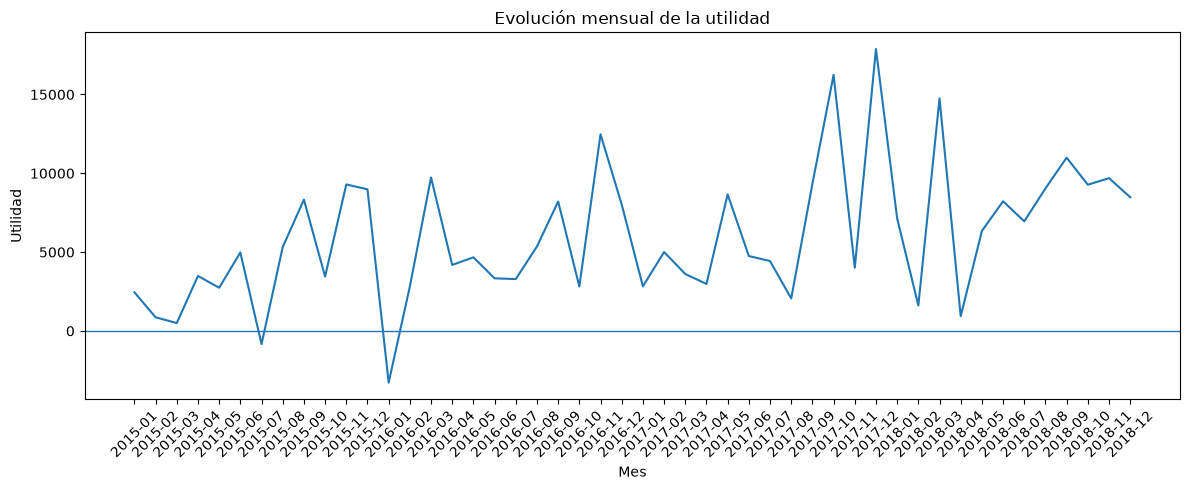

In [382]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["Year-Month"].astype(str),
    monthly_financials["Profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Evolución mensual de la utilidad")
plt.xlabel("Mes")
plt.ylabel("Utilidad")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [383]:
plt.tight_layout()

plt.savefig("../images/utilidad_mensual.png", dpi=300, bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

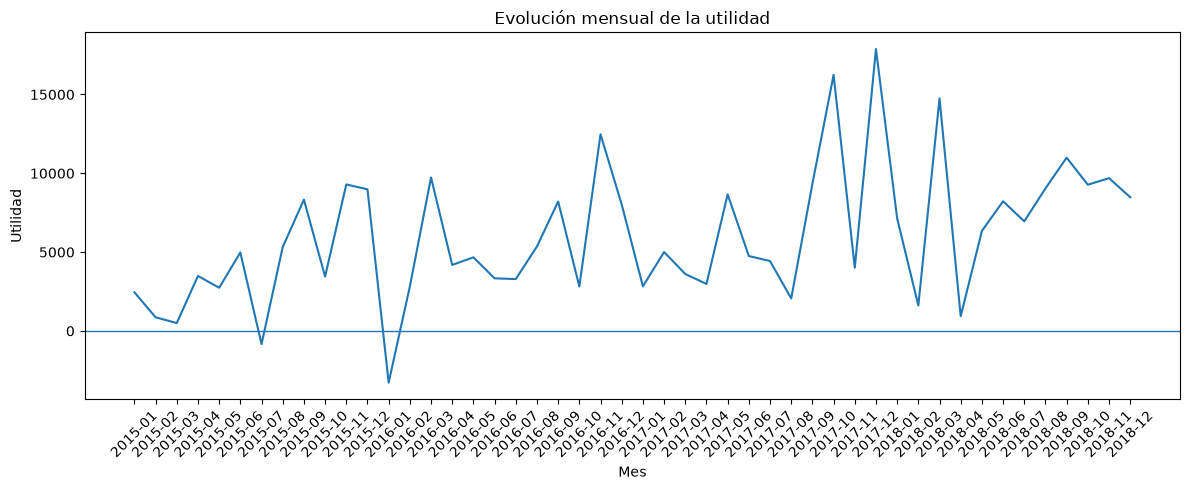

In [384]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_financials["Year-Month"].astype(str),
    monthly_financials["Profit"]
)

plt.axhline(0, linewidth=1)

plt.title("Evolución mensual de la utilidad")
plt.xlabel("Mes")
plt.ylabel("Utilidad")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/utilidad_mensual.png", dpi=300, bbox_inches="tight")

plt.show()